In [254]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import tqdm
import re
import os
import glob
import spectres
from astropy import units as u

%matplotlib inline

In [255]:
SPS_HOME = os.path.abspath(os.path.join(os.getcwd(), '..'))
# SPS_HOME = os.getenv('SPS_HOME')
# SPS_HOME = SPS_HOME.replace('fsps', 'fsps_dev')  # -> I call my development folder for fsps 'fsps_dev' to keep it separate from my working fsps installation

# choose one metallicity value for this run
zfraci = 1.
zstr = 'MW'
composition = 'WN'

print(SPS_HOME)
print(zstr)

/Users/mreefe/Dropbox/Astrophysics/fsps_dev
MW


In [256]:
# Define the teff, logg, and logz arrays that cover the grid of UVBLUE models
zfrac = np.array([1/14, 1/7, 1/2, 1.])
logz = np.round(np.log10(zfrac), 1)
logt = np.round(np.arange(4.65, 5.34, 0.05), 2)
teff = 10**logt

print(logt)
print(logz)

[4.65 4.7  4.75 4.8  4.85 4.9  4.95 5.   5.05 5.1  5.15 5.2  5.25 5.3 ]
[-1.1 -0.8 -0.3  0. ]


In [257]:
# Define the wavelength grid that we will resample onto
# -> even logarithmic spacing by ~5% of the current wavelength
w_1 = 90. * 1.05**np.arange(0, int(np.log(800/90)/np.log(1.05))) 
# -> finer sampling in the FUV;
w_2 = np.arange(800., 1800., 0.2)
w_3 = np.arange(1800., 9000., 20.)
# -> spacing by ~5% of the current wavelength
w_4 = 9000. * 1.05**np.arange(0, int(np.log(9.99e6/9000)/np.log(1.05))) 

wavelength = np.concatenate((w_1, w_2, w_3, w_4))
print('w_1 = ', len(w_1))
print('w_2 = ', len(w_2))
print('w_3 = ', len(w_3))
print('w_4 = ', len(w_4))
print('length = ', len(wavelength))
print(wavelength)

w_1 =  44
w_2 =  5000
w_3 =  360
w_4 =  143
length =  5547
[9.00000000e+01 9.45000000e+01 9.92250000e+01 ... 8.33190634e+06
 8.74850165e+06 9.18592674e+06]


In [258]:
# wavelength must be in angstroms!
def airtovac(wavelength):
    # see: https://www.astro.uu.se/valdwiki/Air-to-vacuum%20conversion
    s = 1e4 / wavelength
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    # do not alter wavelengths below 2000 angstroms 
    wh = np.where(wavelength < 2000.)[0]
    n[wh] = 1.0
    return wavelength * n

In [259]:
c_ang = 299792458e10

folder = f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/PoWR_{composition}/Z_{zstr}/'
sed_files = glob.glob(os.path.join(folder, 'sed', '*_sed.txt'))
opt_files = glob.glob(os.path.join(folder, 'line-opt', '*_line_calib.txt'))
uv_files = glob.glob(os.path.join(folder, 'line-uv', '*_line_calib.txt'))

sed_files.sort()
opt_files.sort()
uv_files.sort()

sed_files = np.array(sed_files)
opt_files = np.array(opt_files)
uv_files = np.array(uv_files)

# read in the model parameters reference file
params = np.loadtxt(os.path.join(folder, 'sed', 'modelparameters.txt'), skiprows=8, 
    dtype=[('name','<U5'), ('teff',float), ('rtrans',float), ('mass',float), ('logg',float), ('logl',float), ('logmdot',float), ('vinf',int)])

# we will have one model per temperature, averaging over all logg's and mdot's, since WR stars are defined by
# a fairly strict teff-logg relation on the HR diagram
# teff = np.unique(params['teff'])
# logt = np.log10(teff)

# allocate a buffer for all of the spectra at one metallicity
library_in = np.zeros((len(wavelength), len(logt)))

# loop through temperatures
ti = 0
for logti in tqdm.tqdm(logt, total=len(logt)):

    print(logti)

    # find all models with this temperature
    whi = np.where(np.round(np.log10(params['teff']),2) == logti)[0]
    if len(whi) == 0:
        print('No models found')
        ti += 1
        continue

    # get the corresponding model names
    names = params['name'][whi]
    print(f'Found: {names}')

    # find the file name with this index
    finds = []
    for name in names:
        find = np.where([name in filename for filename in sed_files])[0][0]
        finds.append(find)
    finds = np.array(finds)

    fnus = []
    wave0 = None
    # read in each file
    for sed_path, opt_path, uv_path in zip(sed_files[finds], opt_files[finds], uv_files[finds]):

        # read in the text files
        loglam_sed, logflam_sed = np.loadtxt(sed_path, unpack=True, skiprows=5)
        lam_opt, logf_opt = np.loadtxt(opt_path, unpack=True)
        lam_uv,  logf_uv  = np.loadtxt(uv_path,  unpack=True)

        # handle the -100's 
        good = np.where(logflam_sed != -100.)[0]
        loglam_sed = loglam_sed[good]
        logflam_sed = logflam_sed[good]

        # convert from log
        lam_sed = 10**loglam_sed
        f_sed = 10**logflam_sed
        f_opt = 10**logf_opt
        f_uv  = 10**logf_uv

        # renormalize the high-res spectra to smoothly join with the SEDs
        wh_opt = (lam_sed > lam_opt.min()) & (lam_sed < lam_opt.max())
        wh_uv  = (lam_sed > lam_uv.min()) & (lam_sed < lam_uv.max())
        f_opt *= np.nanmedian(f_sed[wh_opt])/np.nanmedian(f_opt)
        f_uv  *= np.nanmedian(f_sed[wh_uv])/np.nanmedian(f_uv)

        # remove the overlapping points from the SED
        good = np.where(~(wh_opt|wh_uv))[0]
        
        # smoothly join
        wave = np.concatenate((lam_sed[good], lam_uv, lam_opt)) 
        flam = np.concatenate((f_sed[good], f_uv, f_opt))
        ss = np.argsort(wave)
        wave = wave[ss]
        flam = flam[ss]

        if wave0 is None:
            wave0 = wave
        else:
            flam = np.interp(wave0, wave, flam)

        # Convert the units
        fnu = flam*wave0**2/c_ang
        fnu /= 4*np.pi

        fnus.append(fnu)
    
    # average over all the models 
    fnu = np.nanmean(fnus, axis=0)

    # normalize such that it integrates to 1
    norm = np.trapz(fnu*c_ang/wave0**2, wave0)
    fnu /= norm

    # perform the flux-conserving resampling onto the output wavelength grid
    # flux_o = spectres.spectres(wavelength, wave_i, flux_i, fill=0., verbose=False)
    fnu_o = np.interp(wavelength, wave0, fnu, left=0., right=0.)

    # insert it into the 3D array
    library_in[:, ti] = fnu_o

    # # plot the new and old spectrum to compare them
    # fig, ax = plt.subplots()
    # for fnui in fnus:
    #     ax.plot(wave0, fnui, 'k-', alpha=0.5)
    # ax.plot(wave0, fnu*norm)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_xlabel('Wavelength (angstrom)')
    # ax.set_ylabel('Flambda')
    # ax.set_xlim(900, 1800)
    # # ax.set_ylim(flux_i[(wave_i > 900) & (wave_i < 1800)].min()*0.98, flux_i[(wave_i > 900) & (wave_i < 1800)].max()*1.02)
    # plt.show()
    # plt.close()

    ti += 1

  0%|          | 0/14 [00:00<?, ?it/s]

4.65
Found: ['06-04' '06-05' '06-06' '06-07' '06-08' '06-09' '06-10' '06-11' '06-12'
 '06-13' '06-14' '06-15' '06-16' '06-17']


  7%|▋         | 1/14 [00:00<00:02,  6.04it/s]

4.7
Found: ['07-04' '07-05' '07-06' '07-07' '07-08' '07-09' '07-10' '07-11' '07-12'
 '07-13' '07-14' '07-15' '07-16' '07-17' '07-18']


 21%|██▏       | 3/14 [00:00<00:02,  5.47it/s]

...

5.05
Found: ['14-09' '14-10' '14-11' '14-12' '14-13' '14-14' '14-15' '14-16' '14-17'
 '14-18' '14-19' '14-20' '14-21']
5.1
Found: ['15-10' '15-11' '15-12' '15-13' '15-14' '15-15' '15-16' '15-17' '15-18'
 '15-19' '15-20' '15-21']
5.15
Found: ['16-11' '16-12' '16-13' '16-14' '16-15' '16-16' '16-17' '16-18' '16-19'
 '16-20' '16-21']


 86%|████████▌ | 12/14 [00:01<00:00,  8.90it/s]

5.2
Found: ['17-12' '17-13' '17-14' '17-15' '17-16' '17-17' '17-18' '17-19' '17-20'
 '17-21']
5.25
Found: ['18-13' '18-14' '18-15' '18-16' '18-17' '18-18' '18-19' '18-20' '18-21']


100%|██████████| 14/14 [00:01<00:00,  7.56it/s]

5.3
Found: ['19-16']


(1e-18, 1e-15)

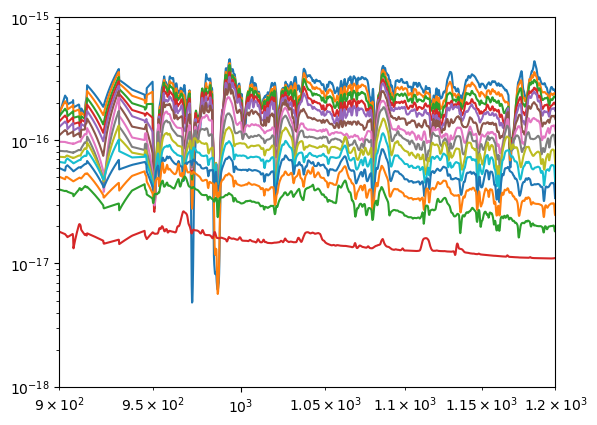

In [260]:
# Plot the spectra
fig, ax = plt.subplots()
for i in range(library_in.shape[1]):
    ax.loglog(wavelength, library_in[:, i], '-')
# ax.set_ylim(0, 1e-16)
ax.set_xlim(900, 1200)
ax.set_ylim(1e-18, 1e-15)

In [261]:
# # Read in WMBasic templates for comparison
# wr = np.zeros((1963,12,5))
# fsps_wr_logt = np.zeros((12,))
# fsps_wr_z = np.zeros((5,))
# with open(os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/CMFGEN_{composition}_Zall.spec')) as f:
#     wwr = np.array([float(vi) for vi in f.readline().split(' ')])
#     for j in range(5):
#         for i in range(12):
#             vals = f.readline()[1:].split(' ')
#             fsps_wr_logt[i] = float(vals[0])
#             fsps_wr_z[j] = float(vals[1])
#             wr[:,i,j] = [float(vi) for vi in f.readline().split(' ')]

# template_folder = os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/PoWR_{composition}/template_plots')
# if not os.path.exists(template_folder):
#     os.makedirs(template_folder)

# for i in range(wr.shape[1]):
#     ii = np.nanargmin(np.abs(fsps_wr_logt[i] - logt))
#     fig, ax = plt.subplots()
#     ax.plot(wwr, wr[:,i,3], label='Smith')
#     ax.plot(wavelength, library_in[:,ii], label='PoWR')
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.set_xlabel(r'Wavelength ($\mathring{\rm A}}$)')
#     ax.set_ylabel(r'$F_\nu$ (normalized)')
#     ax.set_xlim(900, 1800)
#     ax.set_ylim(1e-22, 1e-14)
#     ax.set_title(f'teff={10**fsps_wr_logt[i]}')
#     ax.legend()
#     plt.savefig(os.path.join(template_folder, f'{i}.pdf'), dpi=300, bbox_inches='tight')
#     plt.close()

In [262]:
library_in.shape

(5547, 14)

In [263]:
# Save as a text file with the same format as the format 
zsun = 0.0134
z = zfraci * zsun
# write the output file
with open(os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/PoWR_{composition}/PoWR_{composition}_Zall.spec'), 'a') as f:
    if zstr == 'sSMC':
        f.write(' '.join([f'{wi:.4e}' for wi in wavelength]) + '\n')
    for i in range(len(logt)):
        f.write(f' {logt[i]:.2f} {z:.4f}\n')
        f.write(' '.join([f'{fi:.4e}' for fi in library_in[:,i]]) + '\n')

In [264]:
# save other ancillary files
np.savetxt(os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/PoWR_{composition}/PoWR_{composition}.teff'), logt, fmt='%13.5f')